In [3]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import Modules.analysis as analysis

In [ ]:
sims_dir = '/home/drfrbc/Neural-Modeling/simulations/2025-06-13-12-26-pink_and_delay_no_clustering_fi' # folder containing simulation folders

sim_dirs = [
    os.path.join(sims_dir, sim_dir)
    for sim_dir in os.listdir(sims_dir)
    if os.path.isdir(os.path.join(sims_dir, sim_dir))
]

In [ ]:
# gather spike tables into 1.

import os
import pandas as pd

# Suppose sim_dirs is your list of simulation directories
# import your analysis module
import Modules.analysis as analysis

# Accumulate data in a list of rows
all_rows = []

for sim_dir in sim_dirs:
    # Read dSpike_table.csv
    dSpike_path = os.path.join(sim_dir, "dSpike_table.csv")
    if not os.path.exists(dSpike_path):
        print(f"Skipping {sim_dir}, file not found.")
        continue
    df = pd.read_csv(dSpike_path)
    
    # Get CI_amplitude from parameters
    try:
        params = analysis.DataReader.load_parameters(sim_dir)
        CI_amplitude = params.h_i_amplitude
    except Exception as e:
        print(f"Error loading parameters from {sim_dir}: {e}")
        CI_amplitude = None

    # Add sim_dir and CI_amplitude columns
    df['sim_dir'] = sim_dir
    df['CI_amplitude'] = CI_amplitude
    
    # Append to master list
    all_rows.append(df)

# Combine all rows into one DataFrame
all_data = pd.concat(all_rows, ignore_index=True)


--No graphics will be displayed.


In [6]:
all_data

,Unnamed: 0,Segment_Type,Total_NMDA_Spikes,Total_NA_Spikes,Total_CA_Spikes,Soma_Spike_Rate,sim_dir,CI_amplitude
0,0,apic,2737.6,45.2,50.2,0.8,/home/drfrbc/Neural-Modeling/simulations/2025-...,-0.5
1,1,dend,3616.8,55.2,0.0,0.8,/home/drfrbc/Neural-Modeling/simulations/2025-...,-0.5
2,0,apic,2794.2,44.4,51.0,3.6,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0
3,1,dend,3628.8,55.2,0.0,3.6,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0
4,0,apic,2849.6,44.4,50.4,9.4,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.5
5,1,dend,3635.6,55.2,0.0,9.4,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.5
6,0,apic,2895.6,44.4,42.2,13.6,/home/drfrbc/Neural-Modeling/simulations/2025-...,1.0
7,1,dend,3643.0,55.2,0.0,13.6,/home/drfrbc/Neural-Modeling/simulations/2025-...,1.0
8,0,apic,2932.4,44.4,42.2,17.8,/home/drfrbc/Neural-Modeling/simulations/2025-...,1.5
9,1,dend,3646.2,55.2,0.0,17.8,/home/drfrbc/Neural-Modeling/simulations/2025-...,1.5


In [7]:
apical_data = all_data[all_data['Segment_Type'] == 'apic']

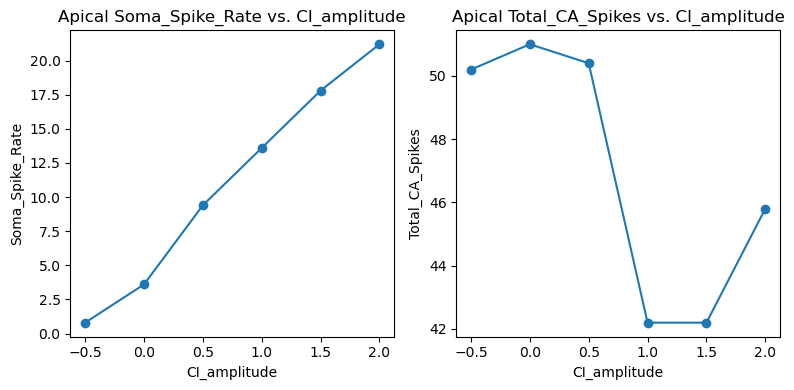

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. CI amplitude')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. CI amplitude')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()